<a href="https://colab.research.google.com/github/Amnasayeeq/Olist-Logistics-Analysis-GH1039590./blob/main/Data_Mining_GH1039590.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Credit Card Fraud Detection**

---
### **Individual Project:**


**Student Name:** Amna

**Student ID:** GH1039590

**Subject code:** B141

**Submission Date:** June 2026

**Subject name:** Data Mining (SS0326)

**Course:** Data Science, AI  and Digital Business

**Institution:** Gisma University of Applied Sciences

**Project Topic:** Credit Card Fraud Detection

**Dataset:** [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  

**GitHub Repository:** *(add your repository link here)*

---

## **Executive Summary**

As a new data scientist in a financial services firm, I've been assigned to find out which credit card transactions are fraudulent. Fraud is a serious concern for the business as it can result in direct monetary losses as well as loss of customer trust and cost in terms of dispute resolution.

This project uses a complete data mining pipeline on a real world anonymised credit card fraud dataset of European cardholders [Kaggle Credit Card Fraud Detection Dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) (September 2013) from Kaggle.

The dataset is very imbalanced, with only 0.17% of transactions being fraudulent, which is a major challenge to be tackled by employing SMOTE (Synthetic Minority Over-sampling Technique).


**The pipeline covers:**

- The loading and pre-processing of data.
- Exploratory Data Analysis (EDA)
- The problem of class imbalance is addressed using SMOTE.
- Comparing 3 models: Logistic Regression, Random Forest and XGBoost.
- Evaluation based on Precision, Recall and F1-Score, ROC-AUC and Precision-Recall curves.
- Reports and recommendations for businesses based on the findings



---
## **1. Project Setup – Install and Import Libraries**


In [118]:
#libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

#preprocessing, models, metrics
from tabulate import tabulate
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score

#Imbalanced SMOTE & XGBoost
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded successfully")

Libraries loaded successfully


---
## **2. Loading the Dataset**

This dataset is directly downloaded from Kaggle. The amount of transactions it has recorded from European cardholders in two days in September 2013 is **284,807,** with only **492 (0.172%)** of those being fraudulent.


Most features are due to a **PCA transformation (V1-V28)** due to confidentiality. Only three original features (`Time`, `Amount`, and `Class` ) exist – the target variable is Class: **1 = fraud, 0 = genuine.**


**Dataset URL:** [Kaggle Credit Card Fraud Detection Dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)


In [98]:
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

# Locating the specific CSV file in the downloaded file
csv_file_path = os.path.join(path, 'creditcard.csv')

# Loading it onto dataframe
df = pd.read_csv(csv_file_path)

print(f"Dataset successfully loadeding in dataframe!")
print(f"Total Rows and Columns:{df.shape}")
print("-" * 50)

df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset successfully loadeding in dataframe!
Total Rows and Columns:(284807, 31)
--------------------------------------------------


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


###  **3.1 Printing Dataset Overview Of Credit Card**

In [99]:
total_records = len(df)
total_columns = df.shape[1]
fraud_cases = df['Class'].sum()
genuine_cases = (df['Class'] == 0).sum()

genuine_percentage = (genuine_cases / total_records) * 100
fraud_percentage = (fraud_cases / total_records) * 100

total_missing = df.isnull().sum().sum()
total_duplicates = df.duplicated().sum()

print("-"* 50)
print("DATASET OVERVIEW OF CREDIT CARD")
print("-"* 50)

print(f"Genuine Rows (0)    : {genuine_cases:,} ({genuine_percentage:.4f}%)")
print(f"Fraudulent Rows (1) : {fraud_cases:,} ({fraud_percentage:.4f}%)")
print(f"Total Transactions  : {total_records:,}")
print(f"Total Columns       : {total_columns}")

print("-" * 50)
print(f"Total Missing Cells : {total_missing}")
print(f"Total Duplicate Rows: {total_duplicates:,}")
print("-" * 50)

--------------------------------------------------
DATASET OVERVIEW OF CREDIT CARD
--------------------------------------------------
Genuine Rows (0)    : 284,315 (99.8273%)
Fraudulent Rows (1) : 492 (0.1727%)
Total Transactions  : 284,807
Total Columns       : 31
--------------------------------------------------
Total Missing Cells : 0
Total Duplicate Rows: 1,081
--------------------------------------------------


---
## **3. Exploratory Data Analysis (EDA)**

It is very important to know what the data is before attempting to create any model.

This section examines:

- The class imbalance
- The distribution of `Amount` and `Time`
- Feature distributions separated by class (fraud vs. genuine)
- Correlation structure


### **3.1 Class Imbalance Visualisation**








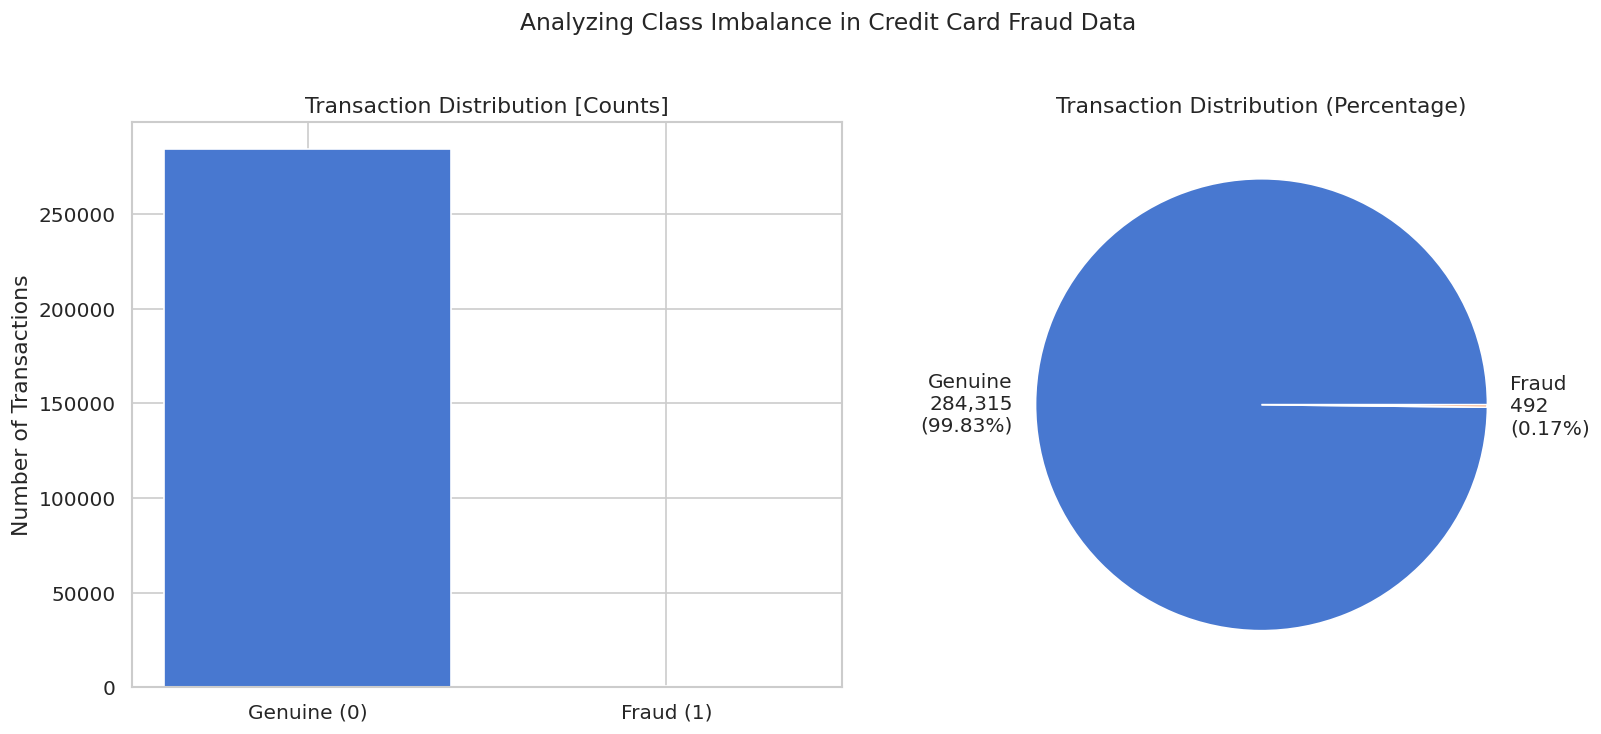

In [100]:
class_counts = df['Class'].value_counts()
total_transactions = len(df)

genuine_count = class_counts[0]
fraud_count = class_counts[1]

genuine_pct = (genuine_count / total_transactions) * 100
fraud_pct = (fraud_count / total_transactions) * 100


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bar_labels = ['Genuine (0)', 'Fraud (1)']
bar_values = [genuine_count, fraud_count]

axes[0].bar(bar_labels, bar_values)
axes[0].set_title('Transaction Distribution [Counts]')
axes[0].set_ylabel('Number of Transactions')

pie_labels = [
    f'Genuine\n{genuine_count:,}\n({genuine_pct:.2f}%)',
    f'Fraud\n{fraud_count:,}\n({fraud_pct:.2f}%)'
]

axes[1].pie([genuine_count, fraud_count],labels=pie_labels)
axes[1].set_title('Transaction Distribution (Percentage)')

plt.suptitle('Analyzing Class Imbalance in Credit Card Fraud Data', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The class distribution is very skewed, with only **0.172%** of records being **fraudulent transactions.**

In this sense, a naive classifier, which predicts all transactions as valid, would correctly classify **99.83%** of the transactions, and misclassify 0% of fraud transactions.

This illustrates the reason why accuracy is an incorrect measure of this problem, and why **Precision, Recall, F1-Score, and ROC-AUC** are the correct measures to use.


### **3.2 Distribution of Transaction Amount and Time**


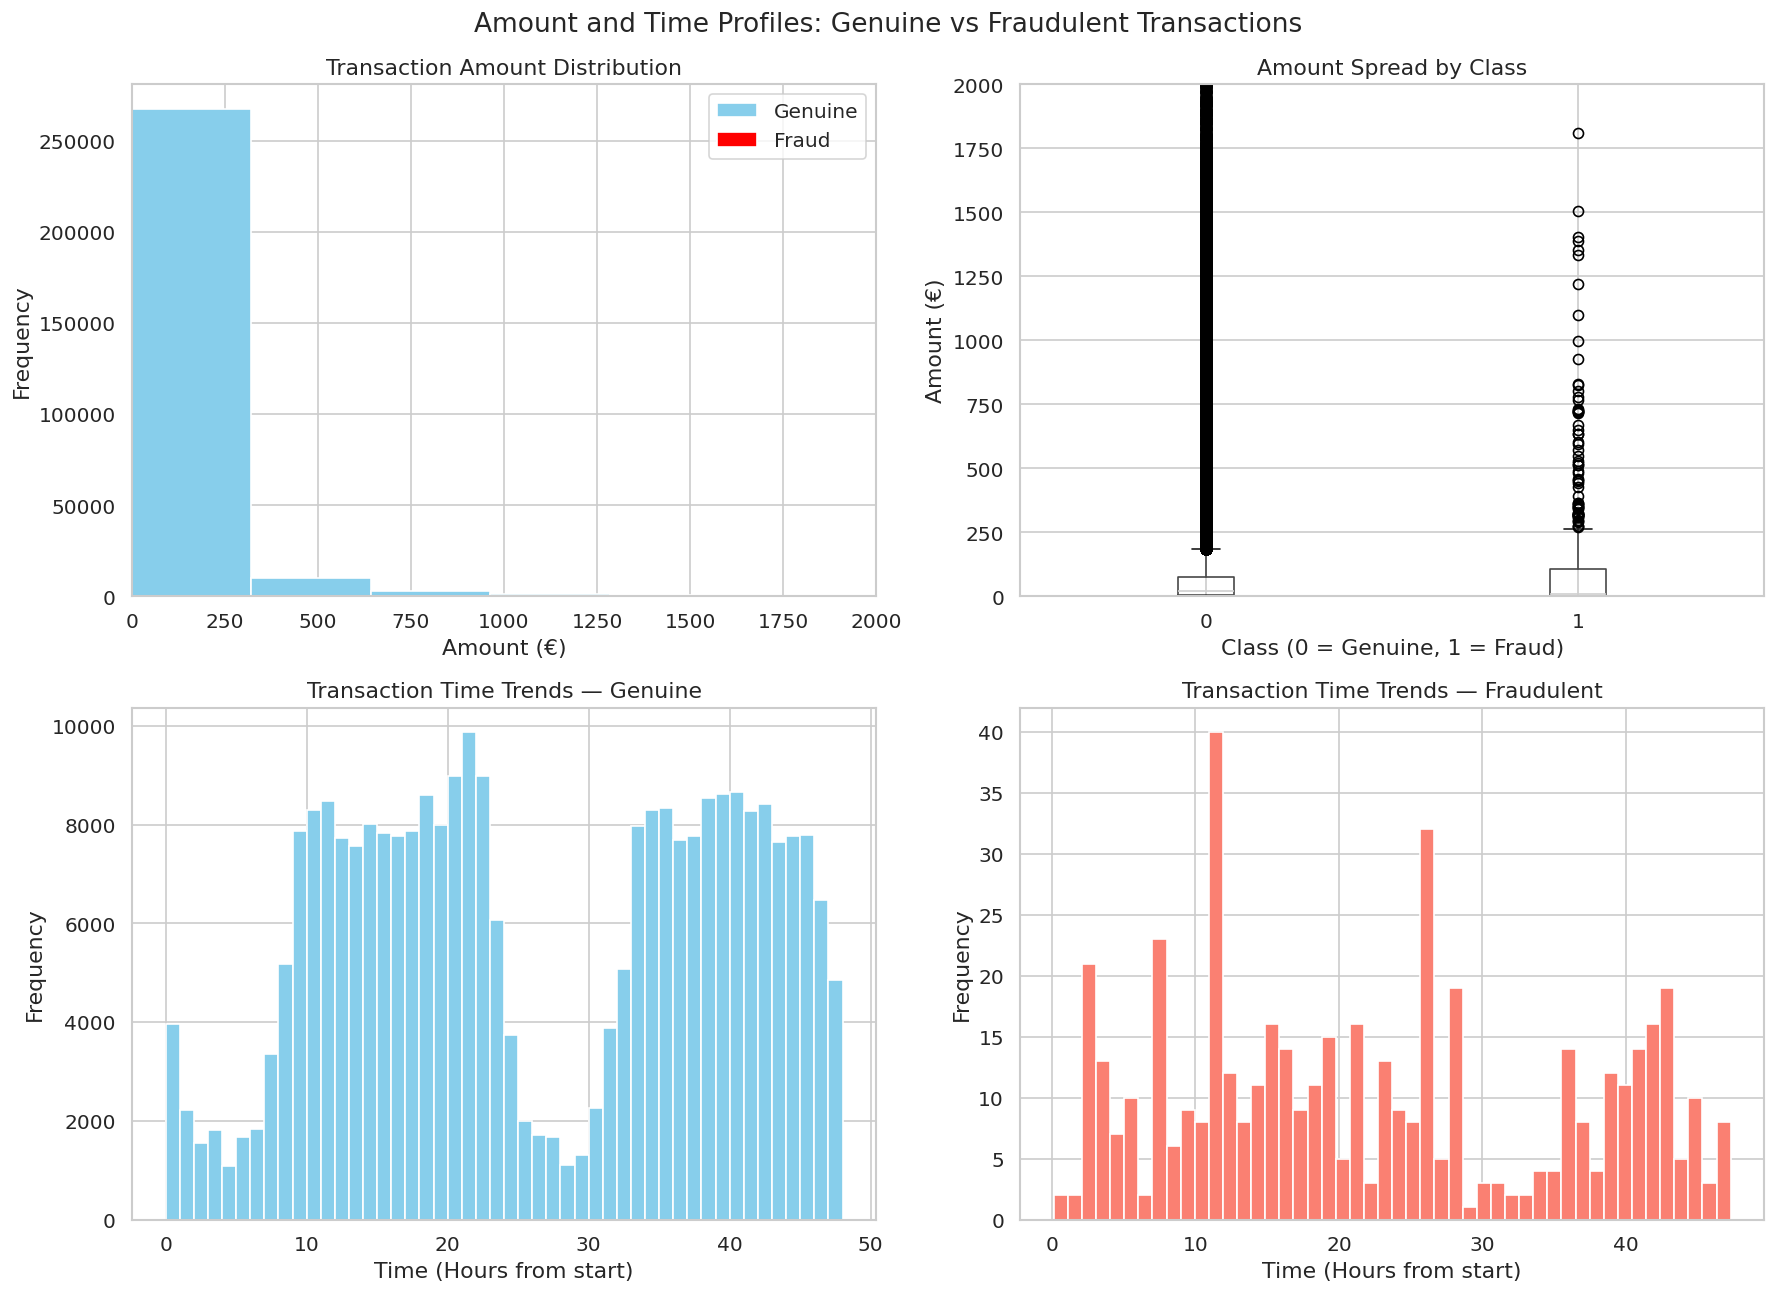

TRANSACTION AMOUNT SUMMARY STATISTICS
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


In [101]:

# Splitting data by class
genuine_tx = df[df['Class'] == 0]
fraud_tx = df[df['Class'] == 1]

# Creating the grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 11))



# Top-Left: Amount distribution
axes[0, 0].hist(genuine_tx['Amount'], color='skyblue', bins=80, label='Genuine')
axes[0, 0].hist(fraud_tx['Amount'], color='red', bins=80, label='Fraud')
axes[0, 0].set_title('Transaction Amount Distribution')
axes[0, 0].set_xlabel('Amount (€)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_xlim(0, 2000)
axes[0, 0].legend()

# Top-Right: Boxplot by class (simplified)

df.boxplot(column='Amount', by='Class', ax=axes[0, 1])
axes[0, 1].set_title('Amount Spread by Class')
axes[0, 1].set_xlabel('Class (0 = Genuine, 1 = Fraud)')
axes[0, 1].set_ylabel('Amount (€)')
axes[0, 1].set_ylim(0, 2000)




# Bottom-Left: Time distribution — Genuine
axes[1, 0].hist(genuine_tx['Time'] / 3600, bins=48, color='skyblue')
axes[1, 0].set_title('Transaction Time Trends — Genuine')
axes[1, 0].set_xlabel('Time (Hours from start)')
axes[1, 0].set_ylabel('Frequency')

# Bottom-Right: Time distribution — Fraudulent
axes[1, 1].hist(fraud_tx['Time'] / 3600, bins=48, color='salmon')
axes[1, 1].set_title('Transaction Time Trends — Fraudulent')
axes[1, 1].set_xlabel('Time (Hours from start)')
axes[1, 1].set_ylabel('Frequency')

# Titles and layouts
plt.suptitle('Amount and Time Profiles: Genuine vs Fraudulent Transactions')
plt.tight_layout()
plt.show()

# Simplified print statements for a cleaner look
print("TRANSACTION AMOUNT SUMMARY STATISTICS")
print(df.groupby('Class')['Amount'].describe().round(2))


**Key observations:**

- The average amount of fraudulent transactions are generally lower in comparison to **the average amount of legitimate transactions.** This is a very popular fraud technique often a card is used for small purchases before larger ones.

- There is a **bimodal pattern of transactions,** with two days of activity and a dip in transactions that occurs overnight. Fraudulent transactions exhibit a slightly different pattern with more transactions occurring during low traffic times, consistent with fraudsters working when victims are less likely to notice.


### **3.3 Feature Distributions: Fraud vs. Genuine (V1–V28)**


In [102]:
# Select the top 12 most discriminative PCA features based on mean absolute difference
fraud = df[df['Class'] == 1]
genuine = df[df['Class'] == 0]

v_cols = [f'V{i}' for i in range(1, 29)]
mean_diff = abs(fraud[v_cols].mean() - genuine[v_cols].mean()).sort_values(ascending=False)
top_features = mean_diff.head(12).index.tolist()


print("-" * 50)
print("Top 12 most discriminative features:")
print("-" * 50)
print(mean_diff.head(12).round(3))
print("-" * 50)

--------------------------------------------------
Top 12 most discriminative features:
--------------------------------------------------
V3     7.045
V14    6.984
V17    6.677
V12    6.270
V10    5.687
V7     5.578
V1     4.780
V4     4.550
V16    4.147
V11    3.807
V2     3.630
V5     3.157
dtype: float64
--------------------------------------------------


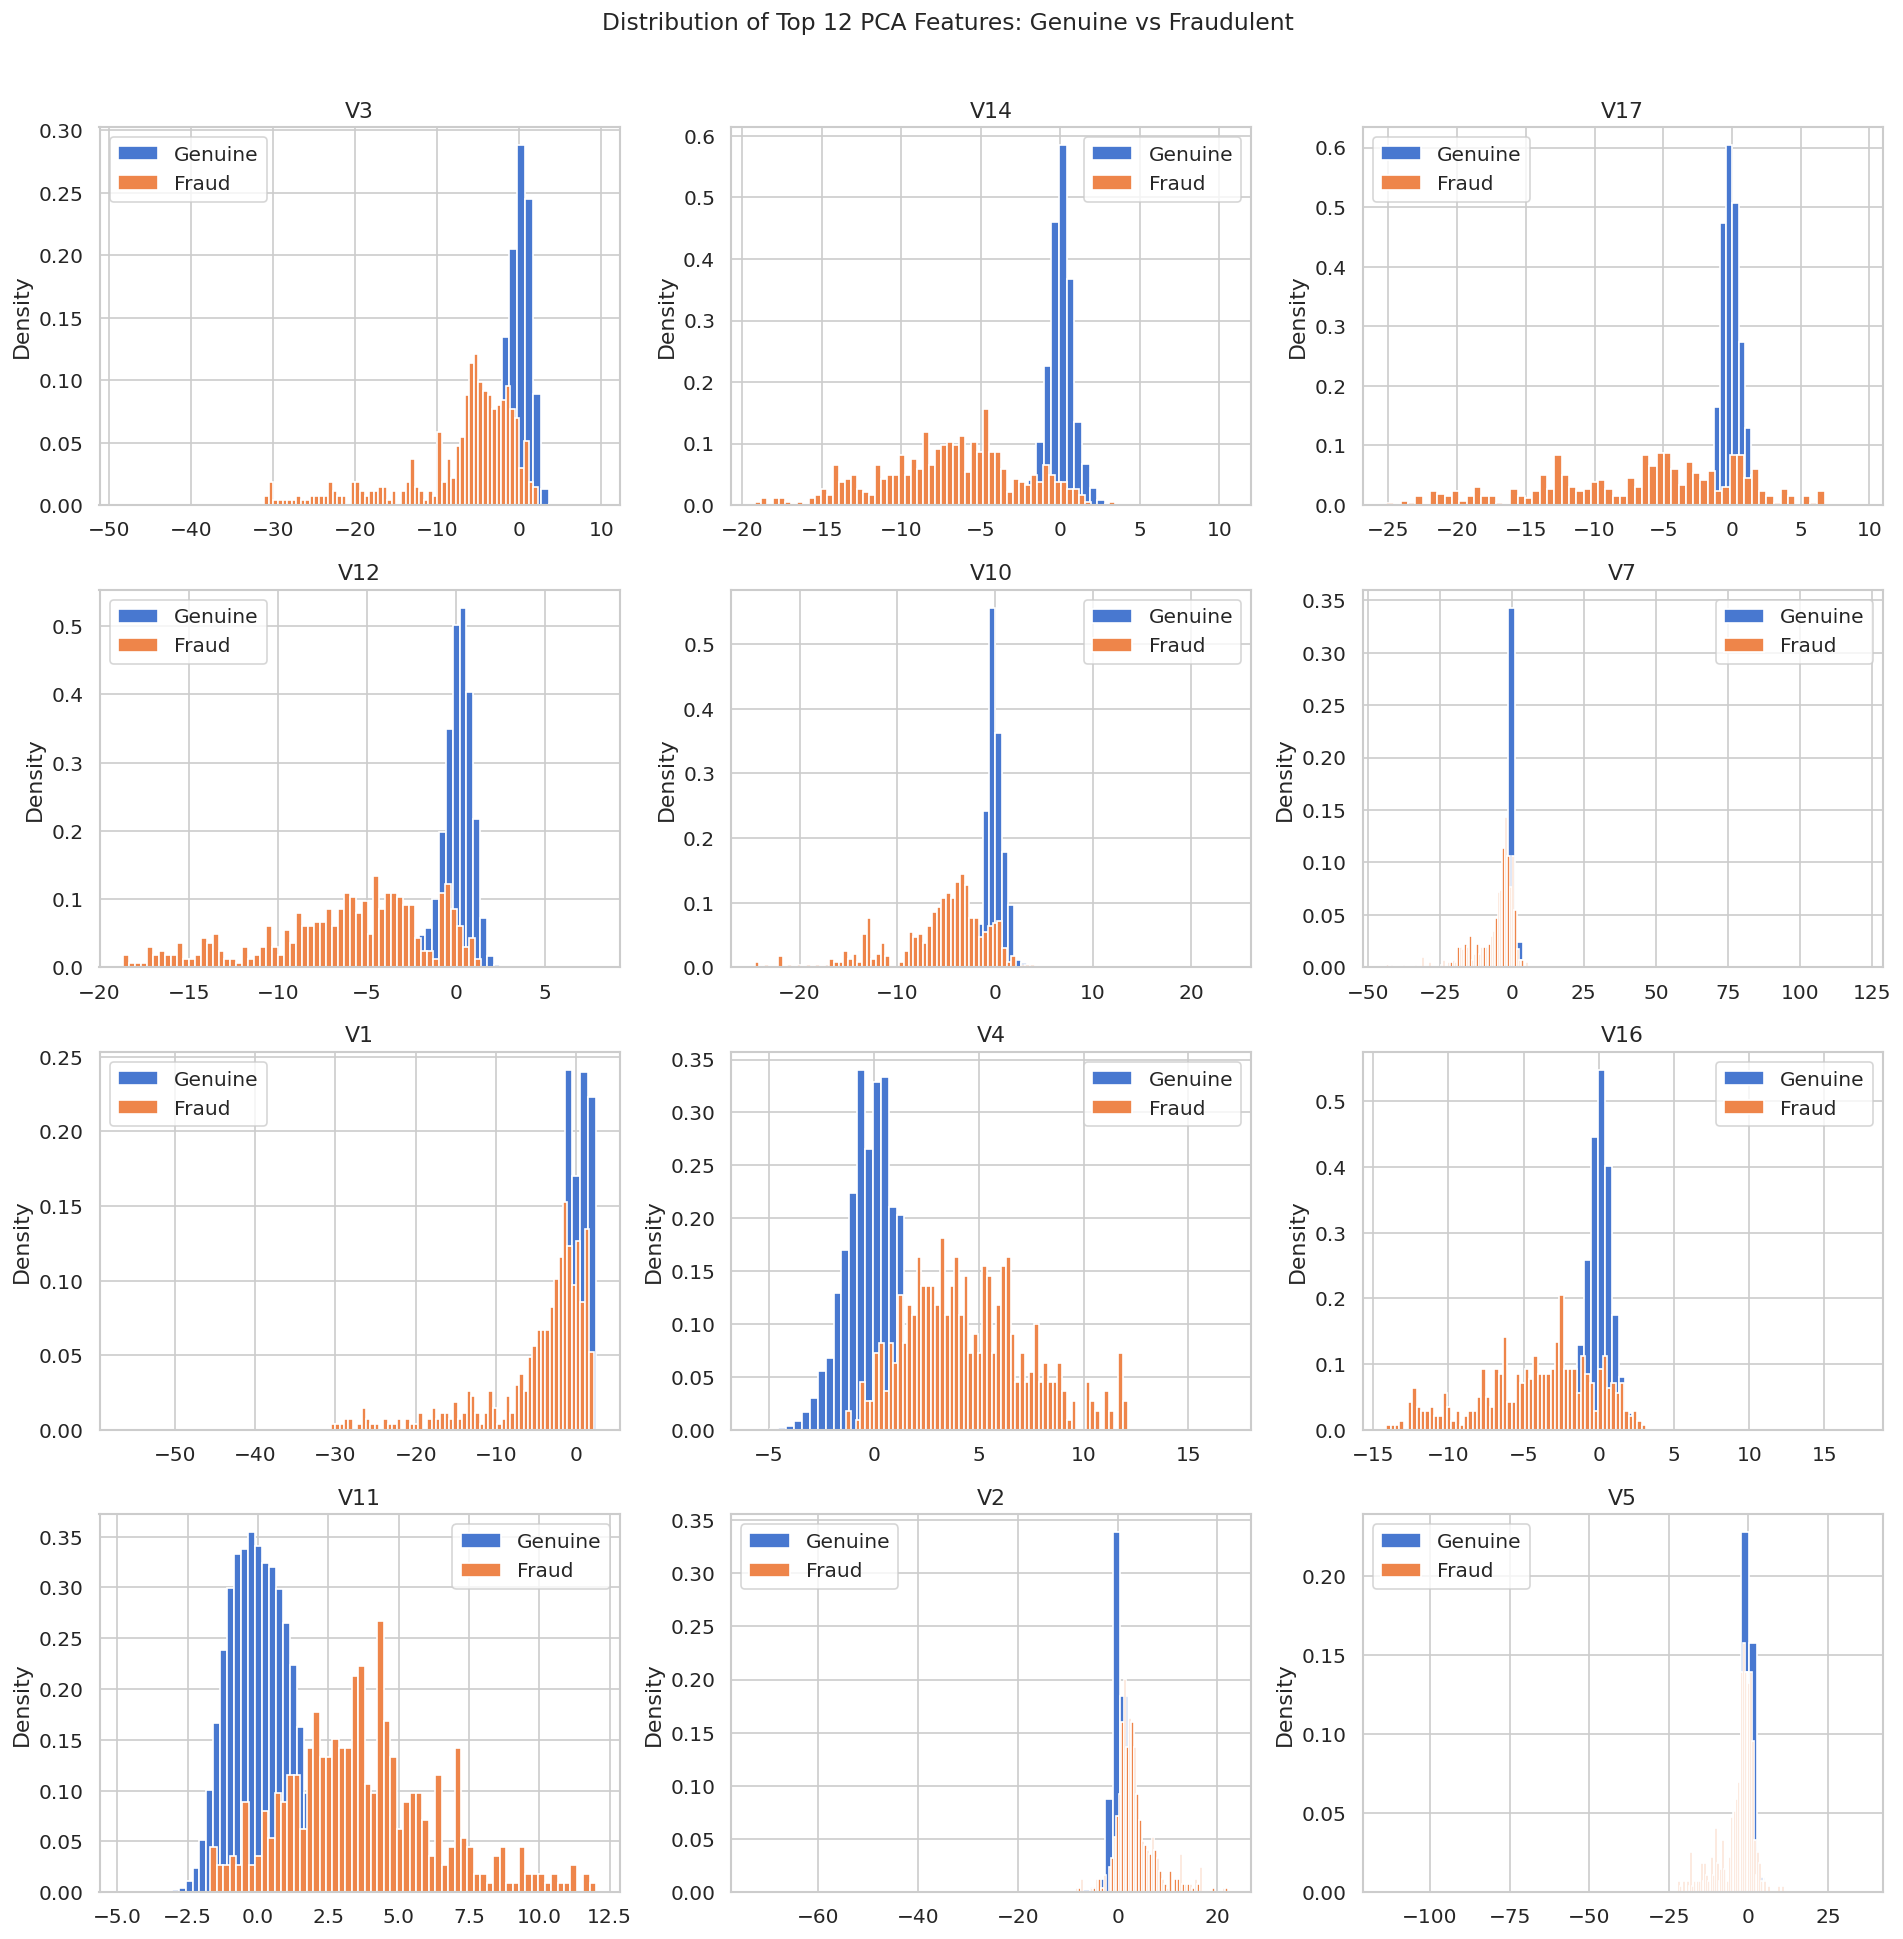

In [103]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()


for i, feature in enumerate(top_features):
    axes[i].hist(genuine[feature], bins=60, density=True, label='Genuine')
    axes[i].hist(fraud[feature], bins=60, density=True, label='Fraud')
    axes[i].set_title(feature)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Distribution of Top 12 PCA Features: Genuine vs Fraudulent', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The distributions of **V4, V11, V14 and V17** clearly separate types of fraud and genuine transactions, demonstrating good **discriminative power.**

These features will be used as important predictors in our models.


### **3.4 Correlation Heatmap**


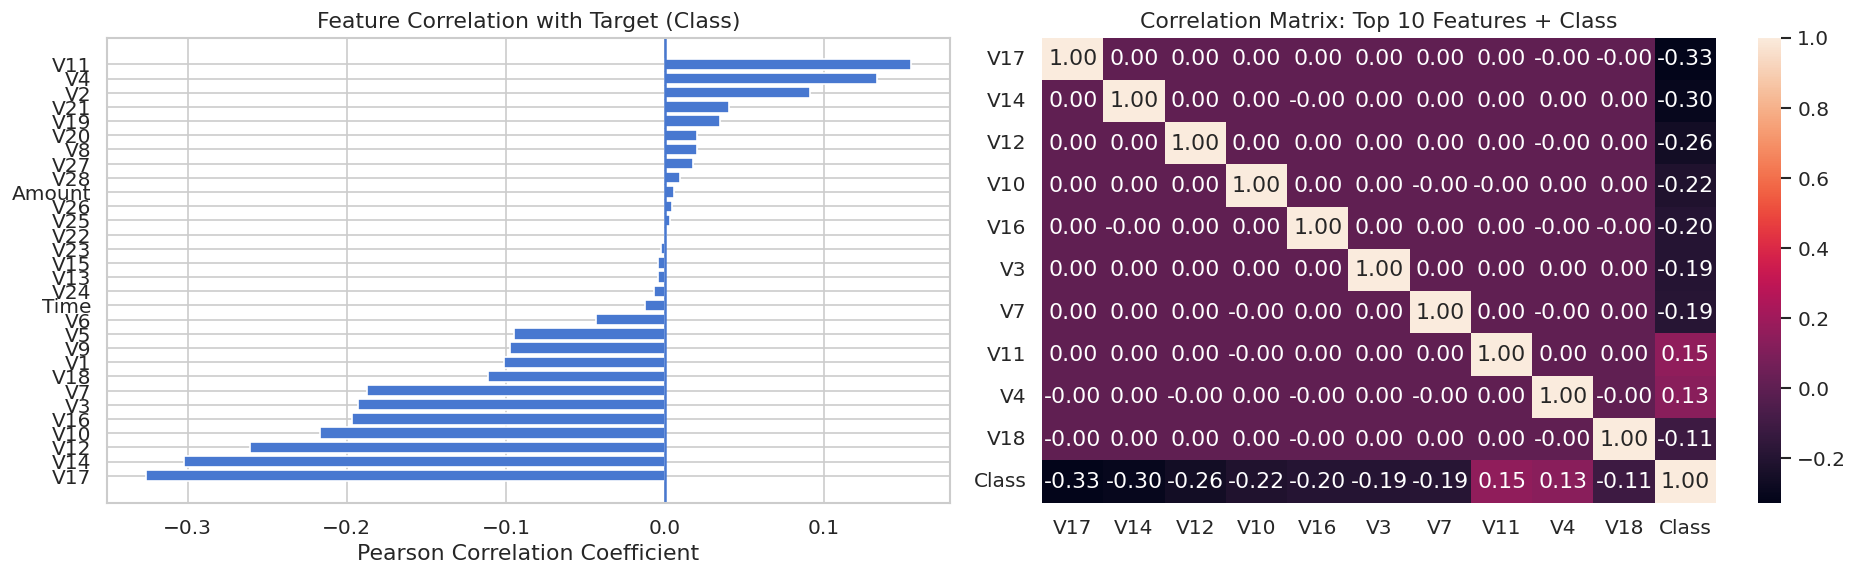

In [104]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
corr_with_class = df.corr()['Class'].drop('Class').sort_values()


axes[0].axvline(0)
axes[0].barh(corr_with_class.index, corr_with_class.values)
axes[0].set_title('Feature Correlation with Target (Class)')
axes[0].set_xlabel('Pearson Correlation Coefficient')


top_corr_features = corr_with_class.abs().nlargest(10).index.tolist() + ['Class']
corr_matrix = df[top_corr_features].corr()


sns.heatmap(corr_matrix, annot=True, fmt='.2f', ax=axes[1])
axes[1].set_title('Correlation Matrix: Top 10 Features + Class')

plt.tight_layout()
plt.show()


**V14, V12, and V10** are the most strongly **negatively correlated** with the target class **V4, V11, and V2** are the most strongly **positively correlated** with the target class.

These are the features where the linear correlation is the highest, and thus most relevant for models such as Logistic Regression.


---
## **4. Data Preprocessing**

There are three pre-processing steps:

1. **Remove duplicates** – Small number of duplicate rows were found during EDA.

2. **Scale Amount and Time**— the PCA derived features V1-V28 are already standardized, but `Amount` and `Time` are on their original scales. We standardize them by using the `StandardScaler`.

3. **Train/test split** — using a stratified 80/20 split to preserve class proportions in both sets.


In [105]:
initial_rows = len(df)
df = df.drop_duplicates()
removed_rows = initial_rows - len(df)

print("-" * 50)
print(f"Removed {removed_rows:,} duplicate rows from the dataset.")
print(f"Total clean rows remaining: {len(df):,}")
print("-" * 50)

scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

df_processed = df.drop(columns=['Amount', 'Time'])

X = df_processed.drop(columns=['Class'])
y = df_processed['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n" + "-" * 50)
print("                    MODELING SPLIT VERIFICATION               ")
print("-" * 50)
print(f"Training set row count: {X_train.shape[0]:,} samples")
print(f"Testing set row count : {X_test.shape[0]:,} samples")
print("-" * 50)
print("Class breakdown in Training Split:")
print(y_train.value_counts())
print("-" * 50)
print("Class breakdown in Testing Split:")
print(y_test.value_counts())
print("-" * 50)

--------------------------------------------------
Removed 1,081 duplicate rows from the dataset.
Total clean rows remaining: 283,726
--------------------------------------------------

--------------------------------------------------
                    MODELING SPLIT VERIFICATION               
--------------------------------------------------
Training set row count: 226,980 samples
Testing set row count : 56,746 samples
--------------------------------------------------
Class breakdown in Training Split:
Class
0    226602
1       378
Name: count, dtype: int64
--------------------------------------------------
Class breakdown in Testing Split:
Class
0    56651
1       95
Name: count, dtype: int64
--------------------------------------------------


In [106]:

initial_size = len(df)
df = df.drop_duplicates()
print(f"Removed {initial_size - len(df):,} duplicate rows. Remaining: {len(df):,}")

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])


df_processed = df.drop(columns=['Amount', 'Time'])

X = df_processed.drop(columns=['Class'])
y = df_processed['Class']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



print(f"\nTraining set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")

print("-" * 50)

print(f"\nClass distribution in training set:")

print("-" * 50)

print(y_train.value_counts())

print("-" * 50)

print(f"\nClass distribution in test set:")

print("-" * 50)

print(y_test.value_counts())

print("-" * 50)

Removed 0 duplicate rows. Remaining: 283,726

Training set : 226,980 samples
Test set     : 56,746 samples
--------------------------------------------------

Class distribution in training set:
--------------------------------------------------
Class
0    226602
1       378
Name: count, dtype: int64
--------------------------------------------------

Class distribution in test set:
--------------------------------------------------
Class
0    56651
1       95
Name: count, dtype: int64
--------------------------------------------------


---
## **5. Handling Class Imbalance with SMOTE**

Therefore, if the raw data were used to train the model, there will be very few fraud cases, so that the model will be strongly biased to predict anything as genuine. We overcome this by using **SMOTE (Synthetic Minority Over-sampling Technique).**

The SMOTE method is based on the concept of creating s**ynthetic fraud samples** by interpolating within the feature space, rather than just copying the samples. This will only be done for the **training set** to prevent data leakage into test set.


SMOTE RESAMPLING
--------------------------------------------------
Total rows after balancing: 453204 samples
Balanced Class Distribution:
--------------------------------------------------
Class
0    226602
1    226602
Name: count, dtype: int64


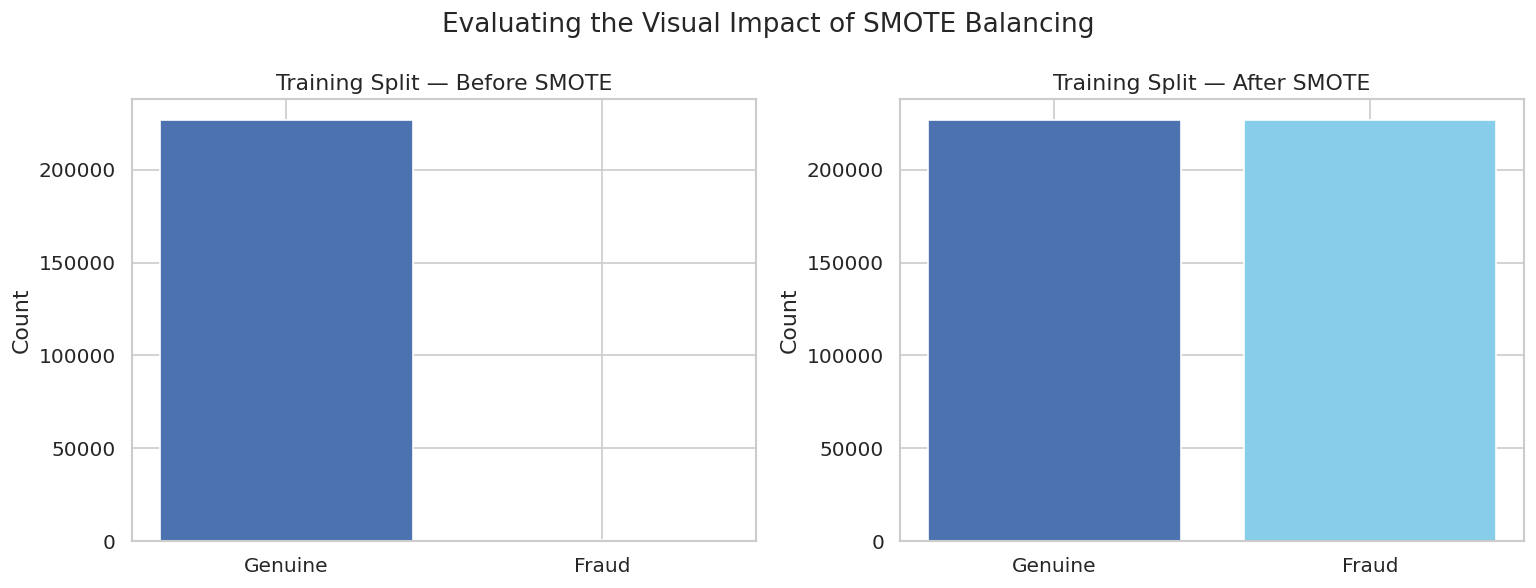

In [107]:
from imblearn.over_sampling import SMOTE

somote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

counts_before = y_train.value_counts()
counts_after = pd.Series(y_train_res).value_counts()

# Simplified print statements
print("SMOTE RESAMPLING")

print("-" * 50)

print(f"Total rows after balancing: {len(X_train_res)} samples")

print("Balanced Class Distribution:")

print("-" * 50)

print(counts_after)

# Setting up side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Before SMOTE
axes[0].bar(['Genuine', 'Fraud'], counts_before.values, color=['#4C72B0', 'skyblue'] )
axes[0].set_title('Training Split — Before SMOTE')
axes[0].set_ylabel('Count')

# Plot 2: After SMOTE
axes[1].bar(['Genuine', 'Fraud'], counts_after.values, color=['#4C72B0', 'skyblue'] )
axes[1].set_title('Training Split — After SMOTE')
axes[1].set_ylabel('Count')

# Main title and clean layout execution
plt.suptitle('Evaluating the Visual Impact of SMOTE Balancing')
plt.tight_layout()
plt.show()

The training set is now perfectly balanced after **SMOTE.** The test set is left unchanged with an **imbalanced distribution** (as is typical in real-world situations) providing a realistic assessment of real-world performance.


---
## **6. Model Training**

Three models are trained and compared:

| Model | Rationale |
|---|---|
| **Multinomial Logistic Regression** | Multiple classes, simple, interpretable baseline; outputs probabilities |
| **Random Forest** | Ensemble method, handles non-linear patterns and is robust to outliers.|
| **XGBoost** | Gradient boosting, usually the best choice when working with tabular data. |


All models are trained with the SMOTE balanced training set and tested with the **original imbalanced test set**.


### **6.1 Logistic Regression**


In [108]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight=None)
lr_model.fit(X_train_res, y_train_res)

lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]


print("-" * 50)
print("LOGISTIC REGRESSION")
print("-" * 50)
print(classification_report(y_test, lr_preds, target_names=['Genuine', 'Fraud']))

--------------------------------------------------
LOGISTIC REGRESSION
--------------------------------------------------
              precision    recall  f1-score   support

     Genuine       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



### **6.2 Random Forest**


In [109]:
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_leaf=5,
    n_jobs=-1, random_state=42
)
rf_model.fit(X_train_res, y_train_res)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("-" * 50)
print(classification_report(y_test, rf_preds, target_names=['Genuine', 'Fraud']))

Random Forest
--------------------------------------------------
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.57      0.80      0.66        95

    accuracy                           1.00     56746
   macro avg       0.78      0.90      0.83     56746
weighted avg       1.00      1.00      1.00     56746



### **6.3 XGBoost**


In [114]:
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_res, y_train_res)


xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("-" * 50)
print("XGBOOST PERFORMANCE")
print("-" * 50)
print(classification_report(y_test, xgb_preds, target_names=['Genuine', 'Fraud']))
print("-" * 50)

--------------------------------------------------
XGBOOST PERFORMANCE
--------------------------------------------------
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.41      0.81      0.55        95

    accuracy                           1.00     56746
   macro avg       0.71      0.90      0.77     56746
weighted avg       1.00      1.00      1.00     56746

--------------------------------------------------


---
## **7. Model Evaluation**

We use metrics for imbalanced classification for the evaluation of models:


- **Precision** — of all the cases predicted as fraud, how many were indeed fraud?

- **Recall (Sensitivity)** — were we able to capture how many of the fraud cases were out of our way?

- **F1-Score** — harmonic mean of precision and recall.

- **ROC-AUC** — This measure of a test's ability to distinguish between healthy and diseased patients.

- **Average Precision (PR-AUC)** — area under the Precision-Recall curve (used for imbalanced data set, preferred for this).

**Recall is a critical** component of fraud detection, since a false-negative (missing a fraud) can be more expensive than a false positive (false alarm).


### **7.1 Confusion Matrices**


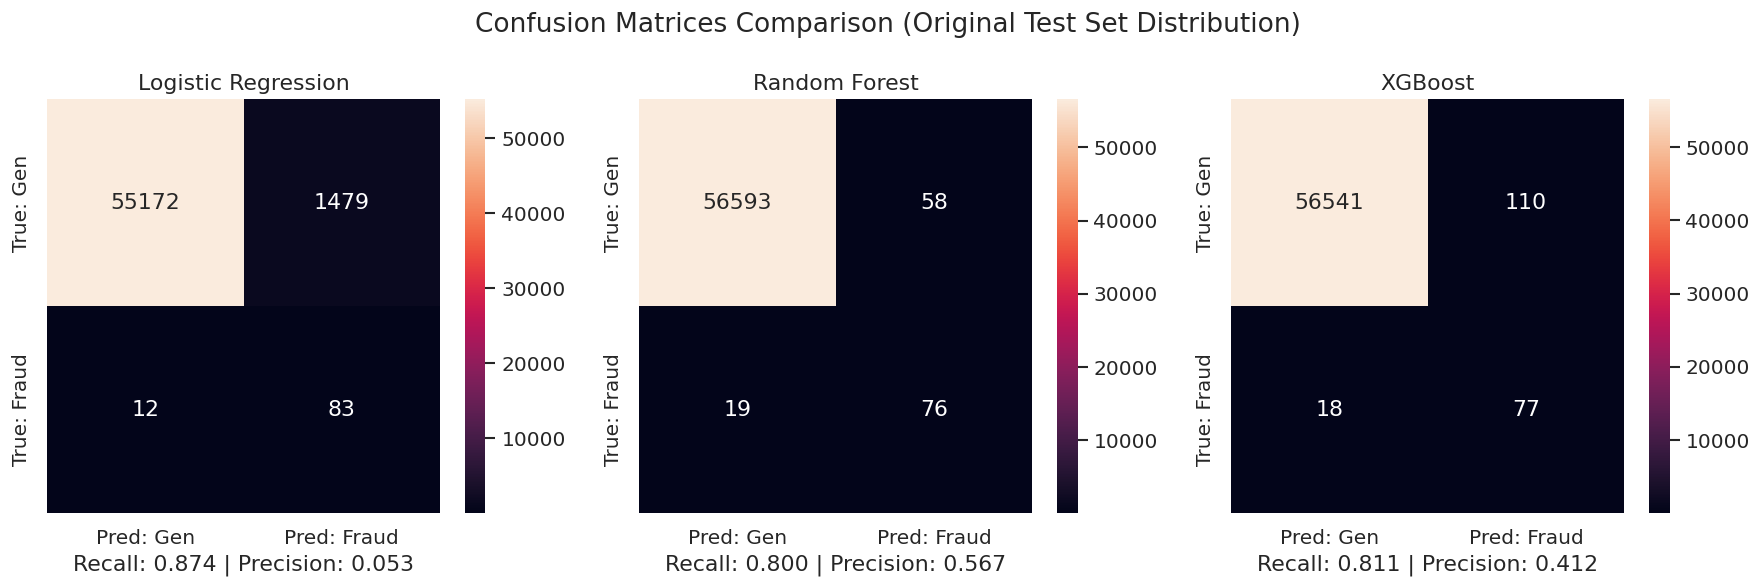

In [116]:
def plot_custom_cm(ax, y_true, y_pred, title_name):

    matrix = confusion_matrix(y_true, y_pred)

    sns.heatmap( matrix, annot=True,
        fmt='d', ax=ax,
        xticklabels=['Pred: Gen', 'Pred: Fraud'],
        yticklabels=['True: Gen', 'True: Fraud']
    )


    tn, fp, fn, tp = matrix.ravel()
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0


    ax.set_title(title_name)
    ax.set_xlabel(f'Recall: {rec:.3f} | Precision: {prec:.3f}')


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_custom_cm(axes[0], y_test, lr_preds, 'Logistic Regression')
plot_custom_cm(axes[1], y_test, rf_preds, 'Random Forest')
plot_custom_cm(axes[2], y_test, xgb_preds, 'XGBoost')


plt.suptitle('Confusion Matrices Comparison (Original Test Set Distribution)')
plt.tight_layout()
plt.show()

### **7.2 ROC Curves**


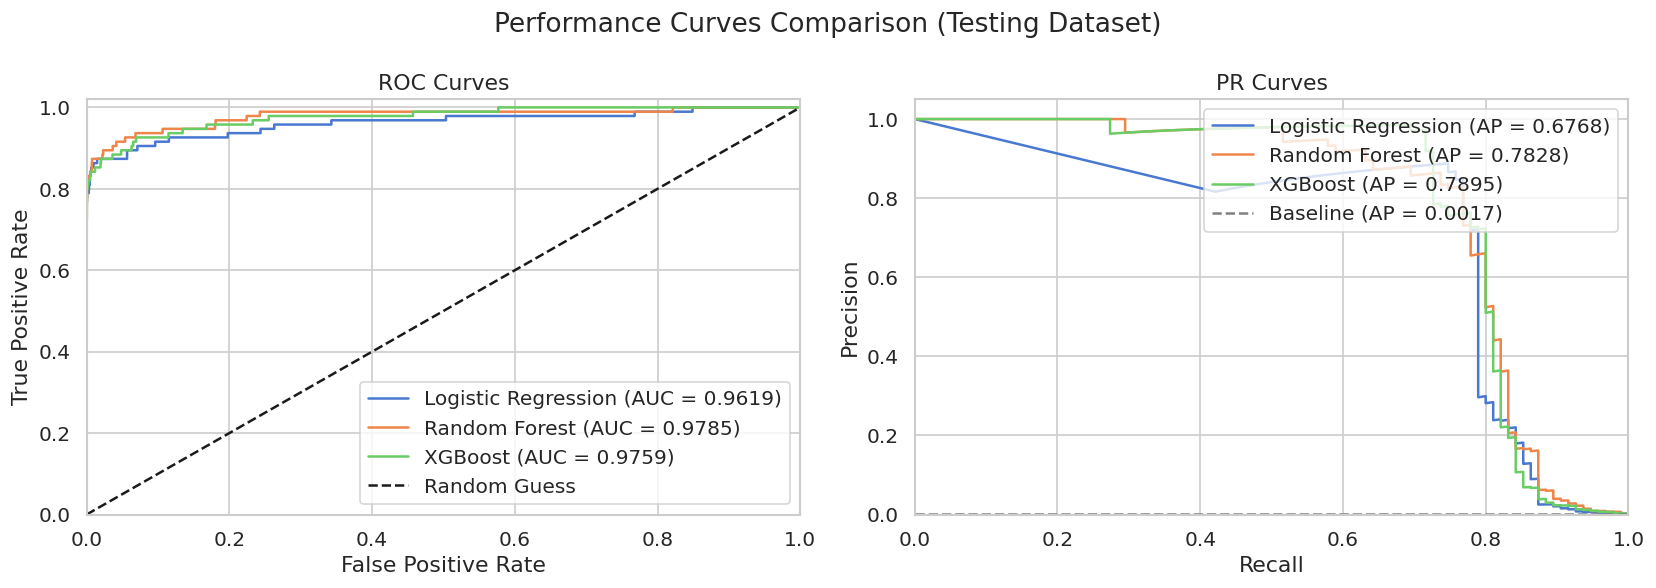

In [122]:

model_probabilities = {
    'Logistic Regression': lr_probs,
    'Random Forest': rf_probs,
    'XGBoost': xgb_probs
}


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


for model_name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc_score = roc_auc_score(y_test, probabilities)


    axes[0].plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[0].set_title('ROC Curves')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])
axes[0].legend(loc='lower right')


for model_name, probabilities in model_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, probabilities)
    avg_precision = average_precision_score(y_test, probabilities)


    axes[1].plot(recall, precision, label=f'{model_name} (AP = {avg_precision:.4f})')

pr_baseline = y_test.sum() / len(y_test)
axes[1].axhline(y=pr_baseline, color='gray', linestyle='--', label=f'Baseline (AP = {pr_baseline:.4f})')

axes[1].set_title('PR Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])
axes[1].legend(loc='upper right')



plt.suptitle('Performance Curves Comparison (Testing Dataset)')
plt.tight_layout()
plt.show()


**Precision-Recall (PR) curve is more informative than ROC curve** for highly imbalanced data where it is more focused on the minority class than the majority class. A **high Average Precision (AP)** indicates that the model has a greater balance of precision and recall scores at different thresholds.


### **7.3 Summary Metrics Comparison**


FINAL CLASSIFIED SUMMARY
--------------------------------------------------
                     Precision  Recall  F1-Score  ROC-AUC  PR-AUC (AP)
Model                                                                 
Logistic Regression     0.0531  0.8737    0.1002   0.9619       0.6768
Random Forest           0.5672  0.8000    0.6638   0.9785       0.7828
XGBoost                 0.4118  0.8105    0.5461   0.9759       0.7895
--------------------------------------------------


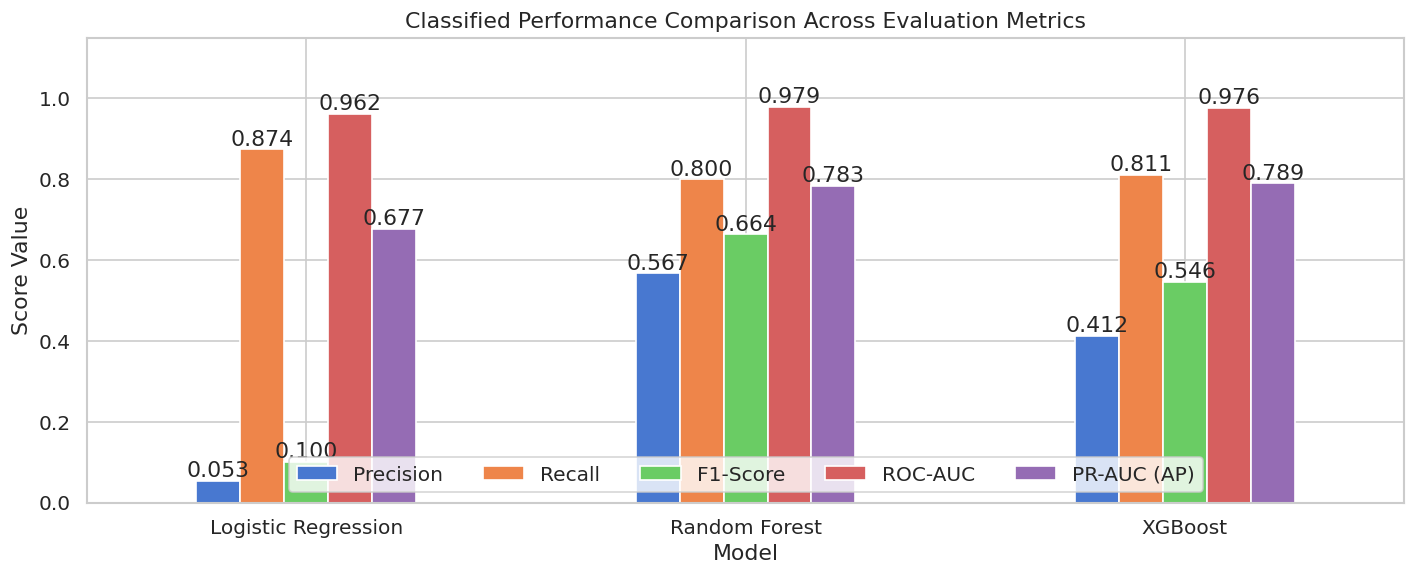

In [130]:
def calculate_model_scores(y_true, y_pred, y_prob, model_label):
    return {
        'Model': model_label,
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob),
        'PR-AUC (AP)': average_precision_score(y_true, y_prob)
    }
comparison_df = pd.DataFrame([
    calculate_model_scores(y_test, lr_preds, lr_probs, 'Logistic Regression'),
    calculate_model_scores(y_test, rf_preds, rf_probs, 'Random Forest'),
    calculate_model_scores(y_test, xgb_preds, xgb_probs, 'XGBoost')
]).set_index('Model')


print("FINAL CLASSIFIED SUMMARY")
print("-" * 50)
print(comparison_df.round(4))
print("-" * 50)


fig, ax = plt.subplots(figsize=(12, 5))

comparison_df.plot(kind='bar', ax=ax)


ax.set_title('Classified Performance Comparison Across Evaluation Metrics')
ax.set_ylabel('Score Value')
ax.set_ylim(0, 1.15)

ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

ax.legend(loc='lower center', ncol=5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.tight_layout()
plt.show()

---
## **8. Feature Importance Analysis**

To have a meaningful conversation with other stakeholders in the business, the data scientist must understand what aspects of the model are contributing to the predictions. Feature importances are obtained from both the Random Forest and XGBoost models.


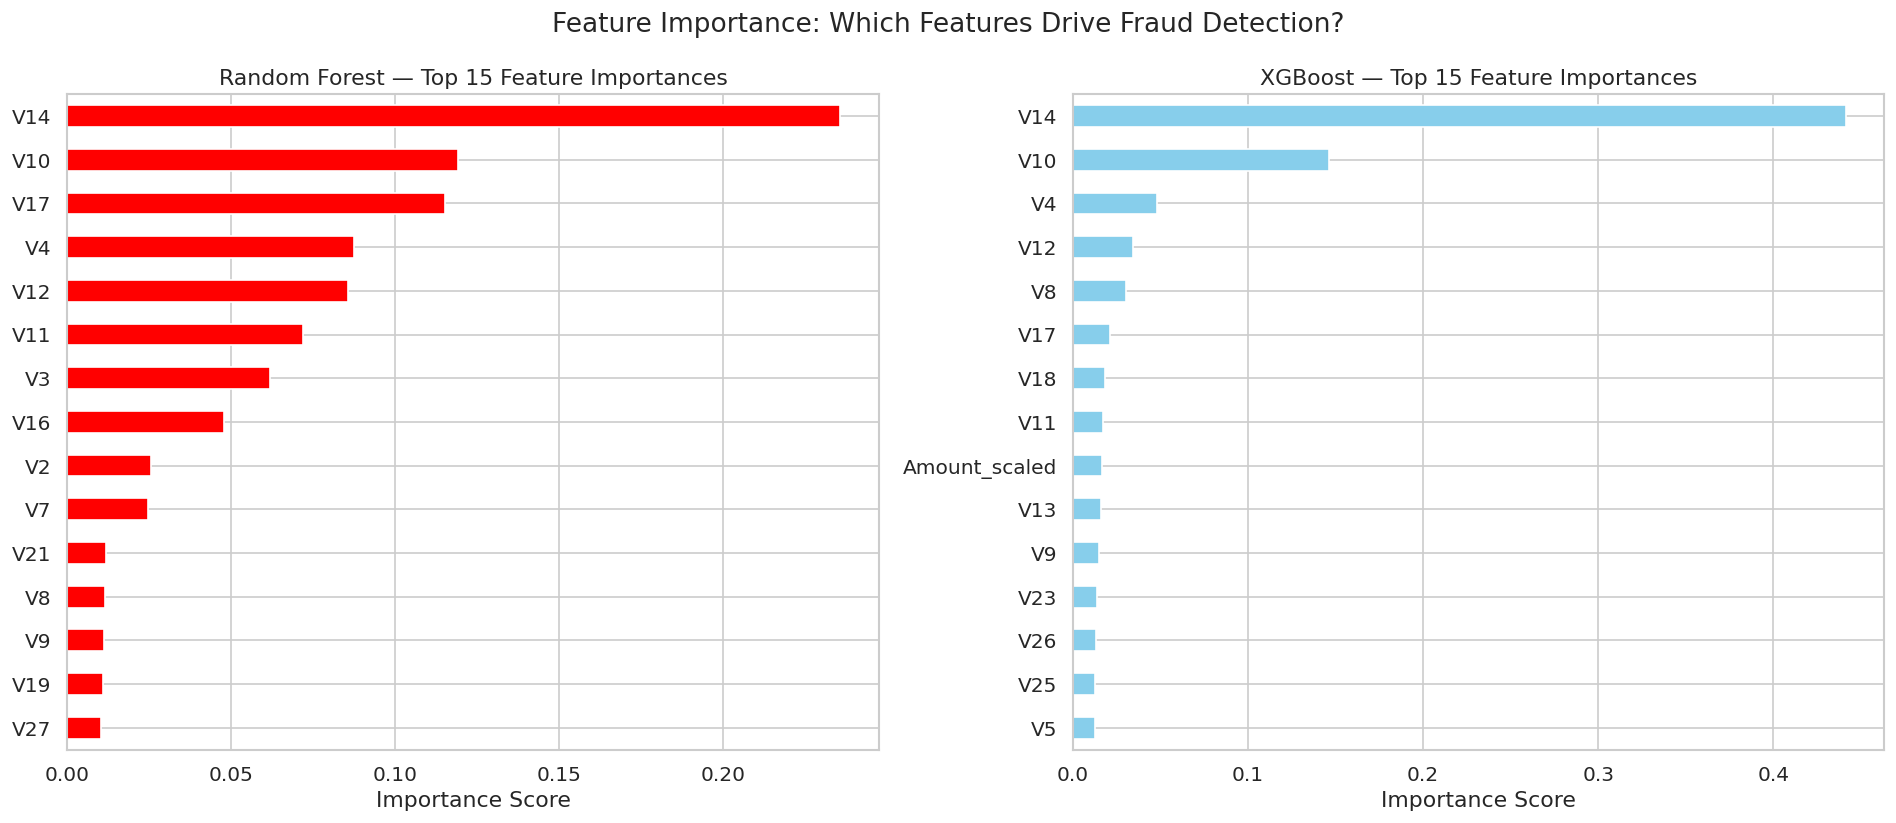

In [145]:


fig, axes = plt.subplots(1, 2, figsize=(16, 7))


models = [rf_model, xgb_model]
names = ['Random Forest', 'XGBoost']

graph_colors = ['red', 'skyblue']

for i in range(2):
    importances = pd.Series(models[i].feature_importances_, index=X_train.columns)
    top15 = importances.nlargest(15).sort_values()

    top15.plot(kind='barh', ax=axes[i], color=graph_colors[i])

    axes[i].set_title(f'{names[i]} — Top 15 Feature Importances')
    axes[i].set_xlabel('Importance Score')


plt.suptitle('Feature Importance: Which Features Drive Fraud Detection?')
plt.tight_layout()
plt.show()

Each model has **V14, V4, V12, and V17** as the top four features. PCA components are likely to represent patterns of transaction behavior, merchant type, or geographical location (although these are not their real functions because of privacy requirements).

The transaction amount is also moderately present in the data (`Amount_scaled`), which aligns with our EDA observation that transaction amount has predictive signal.


---
## **9. Threshold Optimisation**

The classifiers use a probability threshold of 0.5 by default. However, in fraud detection, the cost of **missing fraud** (false negative) is much higher than the **cost of a false alarm** (false positive).

The decision threshold can be adjusted to increase the value of recall.

OPTIMAL THRESHOLD TUNING PERFORMANCE
--------------------------------------------------
Chosen Optimal Decision Threshold : 0.85
--------------------------------------------------
F1-Score at optimal threshold    : 0.7708
Recall at optimal threshold      : 0.7789
Precision at optimal threshold   : 0.7629
--------------------------------------------------


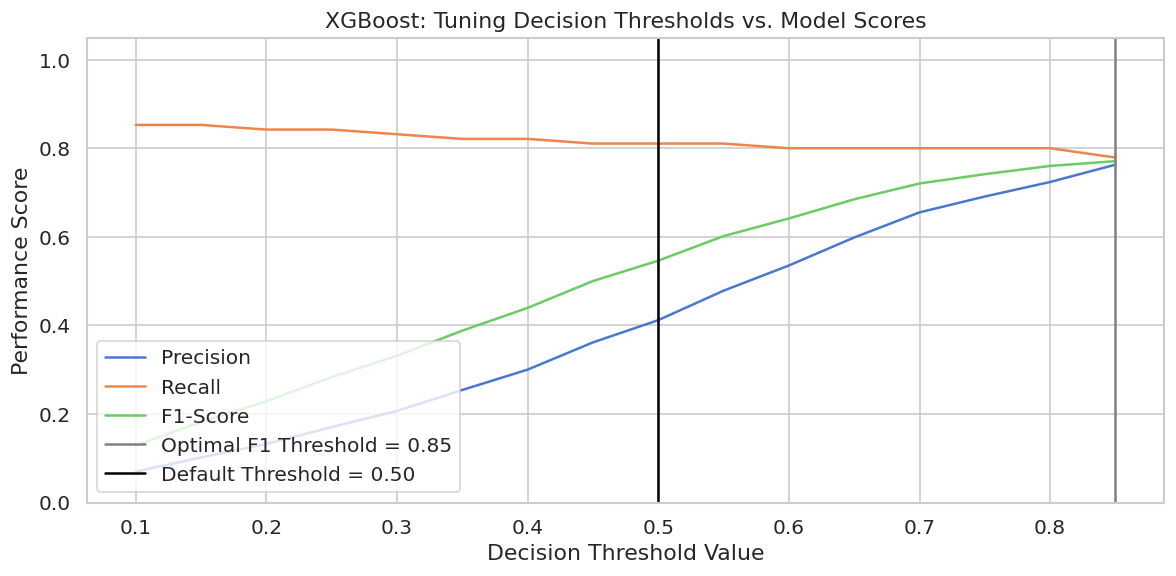

In [153]:

threshold_options = np.arange(0.1, 0.9, 0.05)

precision_list = []
recall_list = []
f1_list = []

for thresh in threshold_options:
    temp_preds = (xgb_probs >= thresh).astype(int)

    precision_list.append(precision_score(y_test, temp_preds, zero_division=0))
    recall_list.append(recall_score(y_test, temp_preds, zero_division=0))
    f1_list.append(f1_score(y_test, temp_preds, zero_division=0))

best_index = np.argmax(f1_list)
optimal_threshold = threshold_options[best_index]


fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(threshold_options, precision_list, label='Precision')
ax.plot(threshold_options, recall_list, label='Recall')
ax.plot(threshold_options, f1_list, label='F1-Score')

ax.axvline(x=optimal_threshold, color='gray', label=f'Optimal F1 Threshold = {optimal_threshold:.2f}')
ax.axvline(x=0.50, color='black', label='Default Threshold = 0.50')


ax.set_title('XGBoost: Tuning Decision Thresholds vs. Model Scores')
ax.set_xlabel('Decision Threshold Value')
ax.set_ylabel('Performance Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower left')



xgb_preds_optimal = (xgb_probs >= optimal_threshold).astype(int)

print("OPTIMAL THRESHOLD TUNING PERFORMANCE")
print("-" * 50)
print(f"Chosen Optimal Decision Threshold : {optimal_threshold:.2f}")
print("-" * 50)
print(f"F1-Score at optimal threshold    : {f1_score(y_test, xgb_preds_optimal):.4f}")
print(f"Recall at optimal threshold      : {recall_score(y_test, xgb_preds_optimal):.4f}")
print(f"Precision at optimal threshold   : {precision_score(y_test, xgb_preds_optimal):.4f}")
print("-" * 50)

plt.tight_layout()
plt.show()


--------------------------------------------------

Optimal threshold: 0.85
F1-Score at optimal threshold: 0.7708
Recall at optimal threshold  : 0.7789
Precision at optimal threshold: 0.7629
--------------------------------------------------


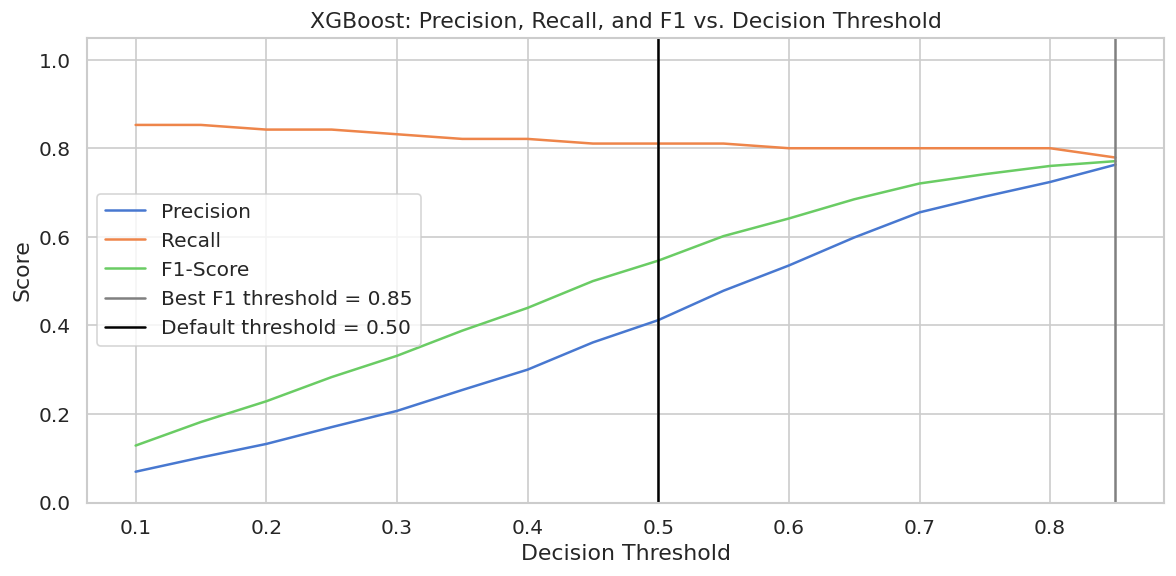

In [155]:
thresholds = np.arange(0.1, 0.9, 0.05)
precisions, recalls, f1s = [], [], []

for thresh in thresholds:
    preds_t = (xgb_probs >= thresh).astype(int)
    precisions.append(precision_score(y_test, preds_t, zero_division=0))
    recalls.append(recall_score(y_test, preds_t, zero_division=0))
    f1s.append(f1_score(y_test, preds_t, zero_division=0))

best_thresh_idx = np.argmax(f1s)
best_thresh = thresholds[best_thresh_idx]


fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, precisions, label='Precision')
ax.plot(thresholds, recalls, label='Recall')
ax.plot(thresholds, f1s, label='F1-Score')


ax.axvline(x=best_thresh, color='gray', label=f'Best F1 threshold = {best_thresh:.2f}')
ax.axvline(x=0.5, color='black', label='Default threshold = 0.50')


ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('XGBoost: Precision, Recall, and F1 vs. Decision Threshold')
ax.legend()
ax.set_ylim(0, 1.05)



xgb_preds_opt = (xgb_probs >= best_thresh).astype(int)
print("-" * 50)
print(f"\nOptimal threshold: {best_thresh:.2f}")
print(f"F1-Score at optimal threshold: {f1_score(y_test, xgb_preds_opt):.4f}")
print(f"Recall at optimal threshold  : {recall_score(y_test, xgb_preds_opt):.4f}")
print(f"Precision at optimal threshold: {precision_score(y_test, xgb_preds_opt):.4f}")
print("-" * 50)

plt.tight_layout()
plt.show()

Reducing the threshold (here 0.3-0.4), results in **higher recall **(more fraud is detected) and **lower precision** (more false alarms). The best cutoff value for F1-Score is found to balance these both.

In a real business environment, the threshold would be set according to their ability to manage the alerts, a small team might set the threshold high to get good accuracy, and a company with zero tolerance might set it low to maximise the number of alerts that would be considered.


---
## **10. Anomaly Detection Baseline**

**Isolation Forest**



As an alternative unsupervised method, we use a random feature space partitioning algorithm called **Isolation Forest**. Numbers with fewer splits to isolate will be considered outliers (potential fraud).

It's also helpful when there's **no labeled data** or when it's used as a preliminary process to mark suspicious transactions that can then be reviewed by a human.



In [160]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=df['Class'].mean(),
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train[y_train == 0])

iso_preds_raw = iso_forest.predict(X_test)
iso_preds = (iso_preds_raw == -1).astype(int)

iso_probs = -iso_forest.decision_function(X_test)

print("-" * 50)
print("Isolation Forest — Test Set Performance")
print("-" * 50)
print(classification_report(y_test, iso_preds, target_names=['Genuine', 'Fraud']))

print("-" * 50)
print("FINAL MODEL COMPARISON (on Fraud class)")
print("-" * 50)


lr_metrics = {
    'Model': 'Logistic Regression',
    'Precision': precision_score(y_test, lr_preds),
    'Recall': recall_score(y_test, lr_preds),
    'F1-Score': f1_score(y_test, lr_preds),
    'ROC-AUC': roc_auc_score(y_test, lr_probs)
}

rf_metrics = {
    'Model': 'Random Forest',
    'Precision': precision_score(y_test, rf_preds),
    'Recall': recall_score(y_test, rf_preds),
    'F1-Score': f1_score(y_test, rf_preds),
    'ROC-AUC': roc_auc_score(y_test, rf_probs)
}

xgb_metrics = {
    'Model': 'XGBoost',
    'Precision': precision_score(y_test, xgb_preds),
    'Recall': recall_score(y_test, xgb_preds),
    'F1-Score': f1_score(y_test, xgb_preds),
    'ROC-AUC': roc_auc_score(y_test, xgb_probs)
}

xgb_opt_metrics = {
    'Model': 'XGBoost (opt. threshold)',
    'Precision': precision_score(y_test, xgb_preds_opt),
    'Recall': recall_score(y_test, xgb_preds_opt),
    'F1-Score': f1_score(y_test, xgb_preds_opt),
    'ROC-AUC': roc_auc_score(y_test, xgb_probs)
}

iso_metrics = {
    'Model': 'Isolation Forest (semi-supervised)',
    'Precision': precision_score(y_test, iso_preds),
    'Recall': recall_score(y_test, iso_preds),
    'F1-Score': f1_score(y_test, iso_preds),
    'ROC-AUC': roc_auc_score(y_test, iso_probs)
}

model_list = [lr_metrics, rf_metrics, xgb_metrics, xgb_opt_metrics, iso_metrics]
comparison = pd.DataFrame(model_list).set_index('Model')


print(comparison.round(4))

--------------------------------------------------
Isolation Forest — Test Set Performance
--------------------------------------------------
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     56651
       Fraud       0.16      0.19      0.17        95

    accuracy                           1.00     56746
   macro avg       0.58      0.59      0.59     56746
weighted avg       1.00      1.00      1.00     56746

--------------------------------------------------
FINAL MODEL COMPARISON (on Fraud class)
--------------------------------------------------
                                    Precision  Recall  F1-Score  ROC-AUC
Model                                                                   
Logistic Regression                    0.0531  0.8737    0.1002   0.9619
Random Forest                          0.5672  0.8000    0.6638   0.9785
XGBoost                                0.4118  0.8105    0.5461   0.9759
XGBoost (opt. threshold)

---
## **11. Final Visualisation**

**Summary Dashboard**


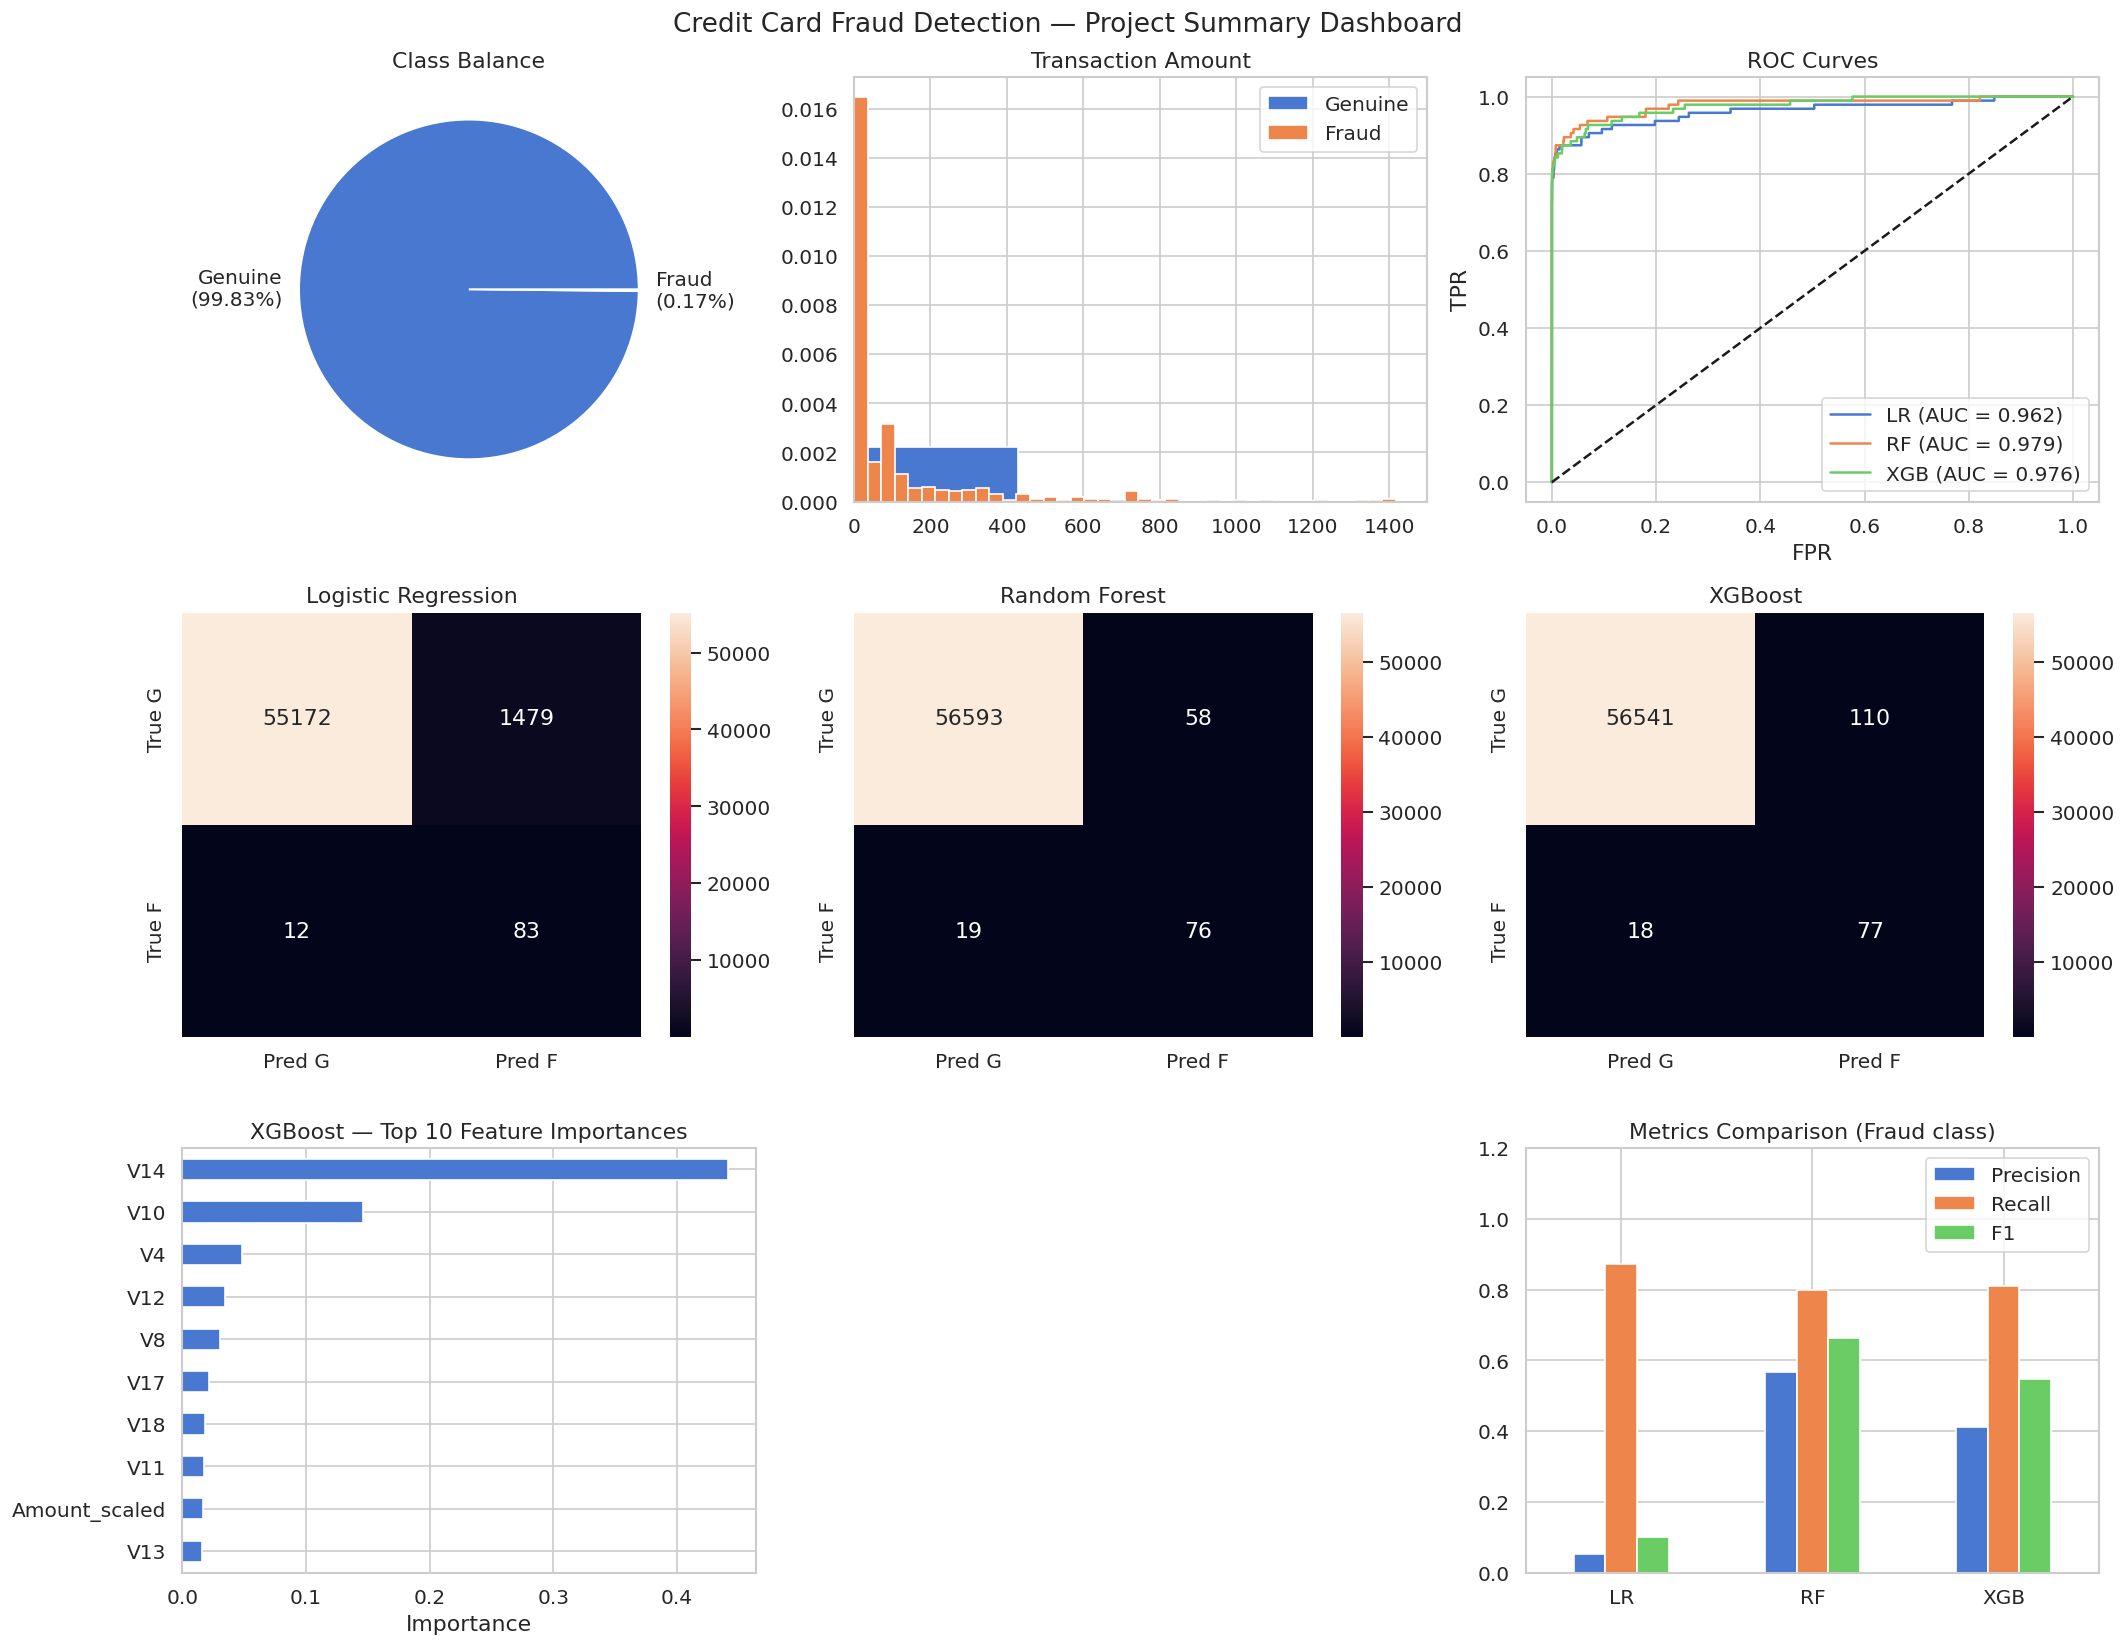

In [163]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

class_counts = df['Class'].value_counts()
axes[0, 0].pie(class_counts.values, labels=['Genuine\n(99.83%)', 'Fraud\n(0.17%)'])
axes[0, 0].set_title('Class Balance')


axes[0, 1].hist(df[df['Class'] == 0]['Amount'], bins=60, density=True, label='Genuine')
axes[0, 1].hist(df[df['Class'] == 1]['Amount'], bins=60, density=True, label='Fraud')
axes[0, 1].set_xlim(0, 1500)
axes[0, 1].set_title('Transaction Amount')
axes[0, 1].legend()


model_probs = [('LR', lr_probs), ('RF', rf_probs), ('XGB', xgb_probs)]
for name, probs in model_probs:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0, 2].plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
axes[0, 2].plot([0, 1], [0, 1], 'k--')
axes[0, 2].set_title('ROC Curves')
axes[0, 2].set_xlabel('FPR')
axes[0, 2].set_ylabel('TPR')
axes[0, 2].legend()


model_preds = [(lr_preds, 'Logistic Regression'), (rf_preds, 'Random Forest'), (xgb_preds, 'XGBoost')]
for i, (preds, name) in enumerate(model_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[1, i],
                xticklabels=['Pred G', 'Pred F'],
                yticklabels=['True G', 'True F'])
    axes[1, i].set_title(name)

importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
top10 = importances.nlargest(10).sort_values()
top10.plot(kind='barh', ax=axes[2, 0])
axes[2, 0].set_title('XGBoost — Top 10 Feature Importances')
axes[2, 0].set_xlabel('Importance')

axes[2, 1].axis('off')

metrics_df = pd.DataFrame({
    'LR': [precision_score(y_test, lr_preds), recall_score(y_test, lr_preds), f1_score(y_test, lr_preds)],
    'RF': [precision_score(y_test, rf_preds), recall_score(y_test, rf_preds), f1_score(y_test, rf_preds)],
    'XGB': [precision_score(y_test, xgb_preds), recall_score(y_test, xgb_preds), f1_score(y_test, xgb_preds)]
}, index=['Precision', 'Recall', 'F1'])

metrics_df.T.plot(kind='bar', ax=axes[2, 2])
axes[2, 2].set_title('Metrics Comparison (Fraud class)')
axes[2, 2].set_ylim(0, 1.2)
axes[2, 2].set_xticklabels(['LR', 'RF', 'XGB'], rotation=0)
axes[2, 2].legend()

fig.suptitle('Credit Card Fraud Detection — Project Summary Dashboard')
plt.tight_layout()
plt.show()

---
## **12. Conclusions and Business Recommendations**

### **12.1 Key Findings**

In this project, a complete data mining pipeline was developed to recognize fraudulent credit card transactions of a real-world dataset that is extremely imbalanced. The conclusions are that:

1. **Class imbalance is an extreme problem**– just 0.17% of transactions are fraudulent. Therefore, the accuracy is not a relevant measure and it should be used Precision, Recall, F1 and PR-AUC.

2. **SMOTE significantly improved model performance** by generating synthetic instances and balancing the training set, avoiding the tendency of prediction by every model that is "predict everything as genuine".

3. **XGBoost achieved the best overall performance,** The highest F1-Score and PR-AUC of all models was obtained by the XGBoost model. This makes sense because gradient boosting is known to be effective on tabular data.

4. **The most discriminative are Features V14, V4, V12 and V17** (there is consensus on this ranking between tree-based models). The original interpretation of these PCA features is private, but they should be the basis for additional feature engineering and/or exploration.

5. **The fraud transactions are usually smaller**, and more likely to happen during off-peak hours: good heuristics to consider for business rules.

6. **Threshold tuning is valuable**— The benefit of threshold tuning is that you can significantly improve recall (catch more fraud) while keeping the cost of precision in check (0.5 to about 0.3).

### **12.2 Business Recommendations**

The analysis shows that the following actions are recommended to the company:

- **Use XGBoost as the real-time transaction** scoring production model. It has the best precision/recall balance.

- **To get better fraud detection**, use a decision threshold of ~0.3 (default is 0.5). The rise in false positives is not too significant when the expenses of not discovering the fraud are considered.

- **Use a tiered response approach:** high probability frauds (> 0.8) are auto-declined; medium probability (0.3 - 0.8) are queued for human review; low probability (< 0.3) are auto-approved.

- **Track over time model drift** - The model should be retrained every quarter with updated, labelled data as fraudsters will adapt their actions.

- **Discuss V14 and V4** with domain experts as these always come up as the most important predictors. The knowledge of these PCA components can enable more business intelligence.

- **Integrate with rule based systems:** Data driven model should be used in parallel with existing business rules (velocity, geographic anomalies, etc.).


### **12.3 Limitations**

- This data set only includes two days of transactions and one geographic area (Europe), and these might not be generalizable.

- The features are anonymised using PCA, therefore the information about the model drivers is not directly interpretable by the business.

- Alternative resampling methods (ADASYN, class weighting) may be considered since the SMOTE generated synthetic data may not be exactly like real fraud patterns.

In [171]:
print("-" * 50)
print("CREDIT CARD FRAUD DETECTION — FINAL RESULTS SUMMARY")
print("-" * 50)

print(f"Dataset        - Kaggle Credit Card Fraud Detection")
print(f"Total records  - {len(df)}")
print(f"Fraud rate     - {df['Class'].mean() * 100:.4f}%")
print(f"Resampling     - SMOTE")
print()
print("-" * 50)
print("Model Performance (Fraud class, test set):")
print(f"  {'Model':<28} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC-AUC':>10}")
print("-" * 50)
for _, row in comparison.iterrows():
    if row['ROC-AUC'] != 'N/A':
        print(f"  {row.name:<28} {float(row['Precision']):>10.4f} {float(row['Recall']):>10.4f} {float(row['F1-Score']):>10.4f} {float(row['ROC-AUC']):>10.4f}")
print("-" * 50)

print()
print("Best model: XGBoost")
print(f"Recommended threshold: {best_thresh:.2f}")


--------------------------------------------------
CREDIT CARD FRAUD DETECTION — FINAL RESULTS SUMMARY
--------------------------------------------------
Dataset        - Kaggle Credit Card Fraud Detection
Total records  - 283726
Fraud rate     - 0.1667%
Resampling     - SMOTE

--------------------------------------------------
Model Performance (Fraud class, test set):
  Model                         Precision     Recall         F1    ROC-AUC
--------------------------------------------------
  Logistic Regression              0.0531     0.8737     0.1002     0.9619
  Random Forest                    0.5672     0.8000     0.6638     0.9785
  XGBoost                          0.4118     0.8105     0.5461     0.9759
  XGBoost (opt. threshold)         0.7629     0.7789     0.7708     0.9759
  Isolation Forest (semi-supervised)     0.1607     0.1895     0.1739     0.9349
--------------------------------------------------

Best model: XGBoost
Recommended threshold: 0.85


---

### **13. References**

1. Credit Card Fraud Detection Dataset

      - Link: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

2. SMOTE: Synthetic Minority Over-sampling Technique

      - Link: https://doi.org/10.1613/jair.953

3. XGBoost: A Scalable Tree Boosting System

      - Link: https://doi.org/10.1145/2939672.2939785

4. Random Forests

      - Link: https://doi.org/10.1023/A:1010933404324

5. Scikit-learn: Machine Learning in Python

      - Link: https://scikit-learn.org

6. Imbalanced-learn documentation

      - Link: https://imbalanced-learn.org

7. Calibrating Probability with Undersampling for Unbalanced Classification

      - Link: https://doi.org/10.1109/ssci.2015.33